<h1><center>Import necessary libraries and data</center></h1>

In [51]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
# set params for anlysis.
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize']=(5,5)

np.set_printoptions(legacy='1.25')

In [41]:
# Import data
cc_df= pd.read_csv('/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/AIML Dataset.csv')

In [42]:
# View the first five rows to ensure data loaded properly.
cc_df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


<h1><center>EDA/Transformations</center></h1>

In [44]:
# View dataset info.
cc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
# Display columns.
cc_df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [46]:
# Value count for is fraud column.
cc_df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [47]:
# Value count for is flagged fraud column.
cc_df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [ ]:
# Check for null values.
cc_df.isnull().sum().sum()

0

In [ ]:
# view the shape of the data.
cc_df.shape

(6362620, 11)

In [ ]:
# Calculate the is fraud percentage.
(cc_df['isFraud'].value_counts()[1]/cc_df.shape[0]*100).round(3)

0.129

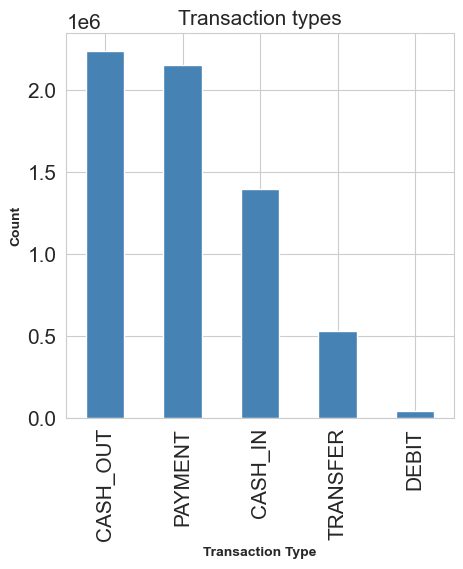

In [ ]:
# Graph transaction types.
cc_df['type'].value_counts().plot(kind='bar', title='Transaction types',
                                  color = 'steelblue')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

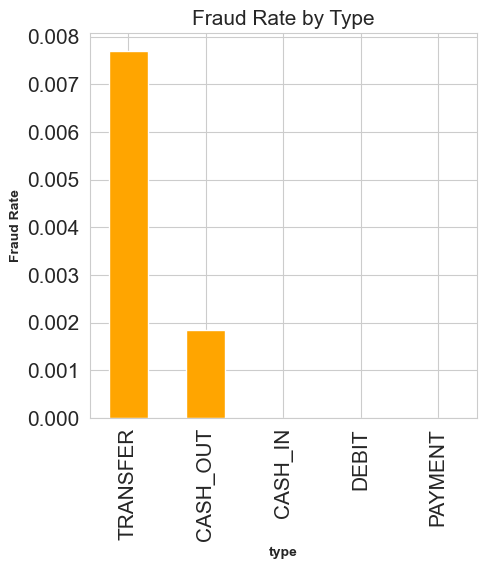

In [64]:
# Graph fraud rate. 
fraud_by_type = cc_df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', title='Fraud Rate by Type', color = 'orange')
plt.ylabel('Fraud Rate')
plt.show()

In [ ]:
# View fraud by type.
fraud_by_type 

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [67]:
# View descriptive statistics for amount column.
cc_df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

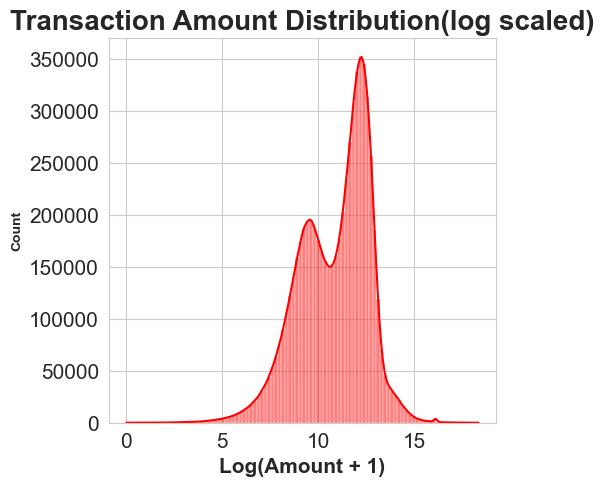

In [68]:
sns.histplot(np.log1p(cc_df['amount']), bins=100, kde=True, color = 'red')
plt.title('Transaction Amount Distribution(log scaled)', fontsize = 20, weight = 'bold')
plt.xlabel('Log(Amount + 1)', fontsize = 15, weight = 'bold')
plt.show()

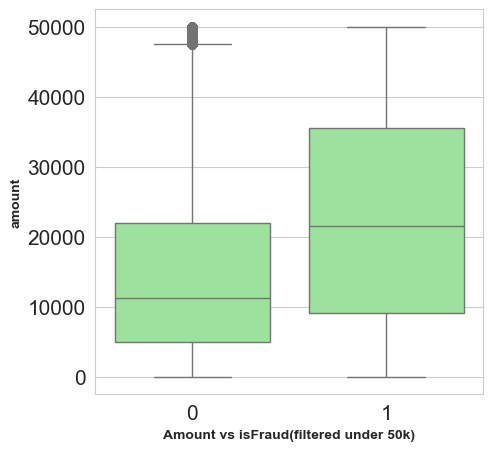

In [73]:
sns.boxplot(data = cc_df[cc_df['amount']< 50000], x = 'isFraud', y = 'amount', color = 'lightgreen')
plt.xlabel('Amount vs isFraud(filtered under 50k)')
plt.show()